In [35]:
!pip install /kaggle/input/rdkit-2025-3-3-cp311/rdkit-2025.3.3-cp311-cp311-manylinux_2_28_x86_64.whl

Processing /kaggle/input/rdkit-2025-3-3-cp311/rdkit-2025.3.3-cp311-cp311-manylinux_2_28_x86_64.whl
rdkit is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


In [1]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
import json
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from pathlib import Path
from tqdm import tqdm

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

SEED = 42
np.random.seed(SEED)

In [18]:
class Config:
    TARGET_LIST = ['Tg', 'FFV', 'Tc', 'Density', 'Rg']
    
    def get_canonical_smiles(self, smiles):
        for i in range(1, 10, 1):
            smiles = smiles.replace(f'[R{i}]', '[*]')
            
        smiles = smiles.replace('[R]', '[*]')
        smiles = smiles.replace('[R\']', '[*]')

        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Invalid SMILES string: {smiles}")
        flag = Chem.SanitizeMol(mol, catchErrors=True)
        
        if flag != Chem.rdmolops.SanitizeFlags.SANITIZE_NONE:
            print(smiles)
            Chem.SanitizeMol(mol, sanitizeOps=Chem.rdmolops.SanitizeFlags.SANITIZE_ALL ^ flag)

        smiles = Chem.MolToSmiles(mol, canonical=True)
        
        return smiles
        
    def vectorize_smiles(self, smiles: str):
        try:
            smiles = self.get_canonical_smiles(smiles)
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return None
        except Exception as e:
            print(f"[ERROR: SMILES parsing] {smiles} → {e}")
            return None
        useless_cols = [    
            'BCUT2D_MWHI',
            'BCUT2D_MWLOW',
            'BCUT2D_CHGHI',
            'BCUT2D_CHGLO',
            'BCUT2D_LOGPHI',
            'BCUT2D_LOGPLOW',
            'BCUT2D_MRHI',
            'BCUT2D_MRLOW',
            'NumRadicalElectrons',
            'SMR_VSA8',
            'SlogP_VSA9',
            'fr_barbitur',
            'fr_benzodiazepine',
            'fr_dihydropyridine',
            'fr_epoxide',
            'fr_isothiocyan',
            'fr_lactam',
            'fr_nitroso',
            'fr_prisulfonamd',
            'fr_thiocyan',
            'MaxEStateIndex',
            'HeavyAtomMolWt',
            'ExactMolWt',
            'NumValenceElectrons',
            'Chi0',
            'Chi0n',
            'Chi0v',
            'Chi1',
            'Chi1n',
            'Chi1v',
            'Chi2n',
            'Kappa1',
            'LabuteASA',
            'HeavyAtomCount',
            'MolMR',
            'Chi3n',
            'BertzCT',
            'Chi2v',
            'Chi4n',
            'HallKierAlpha',
            'Chi3v',
            'Chi4v',
            'MinAbsPartialCharge',
            'MaxPartialCharge',
            'MinPartialCharge',
            'MaxAbsPartialCharge',
            'FpDensityMorgan2',
            'FpDensityMorgan3',
            'Phi',
            'Kappa3',
            'fr_nitrile',
            'SlogP_VSA6',
            'NumAromaticCarbocycles',
            'NumAromaticRings',
            'fr_benzene',
            'VSA_EState6',
            'NOCount',
            'fr_C_O',
            'fr_C_O_noCOO',
            'NumHDonors',
            'fr_amide',
            'fr_Nhpyrrole',
            'fr_phenol',
            'fr_phenol_noOrthoHbond',
            'fr_COO2',
            'fr_halogen',
            'fr_diazo',
            'fr_nitro_arom',
            'fr_phos_ester'
        ]

        descriptors = {}
        # descriptors = {
        #     'MW': Descriptors.MolWt(mol),
        #     'HBA': Descriptors.NOCount(mol),
        #     'HBD': Descriptors.NHOHCount(mol),
        #     'LogP': Descriptors.MolLogP(mol),
        #     'TPSA': Descriptors.TPSA(mol),
        #     'EtherCount': Chem.Fragments.fr_ether(mol),
        #     'EsterCount': Chem.Fragments.fr_ester(mol),
        #     'AmideCount': Chem.Fragments.fr_amide(mol),
        #     'AromaticRingCount': Chem.rdMolDescriptors.CalcNumAromaticRings(mol),
        #     'BertzCT': Descriptors.BertzCT(mol),
        #     'BalabanJ': Descriptors.BalabanJ(mol)
        # }

        compute_desc = lambda mol: {nm: fn(mol) for nm, fn in Descriptors._descList if nm not in useless_cols}
        descriptors = compute_desc(mol)
        morgen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
        fp = morgen.GetFingerprint(mol)
        fp_feat = {idx: int(bit) for idx, bit in enumerate(fp)} 
        descriptors.update(fp_feat)
        return descriptors

config = Config()

In [19]:
class ParticipantVisibleError(Exception):
    pass


# These values are from the train data.
MINMAX_DICT =  {
        'Tg': [-148.0297376, 472.25],
        'FFV': [0.2269924, 0.77709707],
        'Tc': [0.0465, 0.524],
        'Density': [0.748691234, 1.840998909],
        'Rg': [9.7283551, 34.672905605],
    }
NULL_FOR_SUBMISSION = -9999


def scaling_error(labels, preds, property):
    error = np.abs(labels - preds)
    min_val, max_val = MINMAX_DICT[property]
    label_range = max_val - min_val
    return np.mean(error / label_range)


def get_property_weights(labels):
    property_weight = []
    for property in MINMAX_DICT.keys():
        valid_num = np.sum(labels[property] != NULL_FOR_SUBMISSION)
        property_weight.append(valid_num)
    property_weight = np.array(property_weight)
    property_weight = np.sqrt(1 / property_weight)
    return (property_weight / np.sum(property_weight)) * len(property_weight)


def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str) -> float:
    """
    Compute weighted Mean Absolute Error (wMAE) for the Open Polymer challenge.

    Expected input:
      - solution and submission as pandas.DataFrame
      - Column 'id': unique identifier for each sequence
      - Columns 'Tg', 'FFV', 'Tc', 'Density', 'Rg' as the predicted targets

    Examples
    --------
    >>> import pandas as pd
    >>> row_id_column_name = "id"
    >>> solution = pd.DataFrame({'id': range(4), 'Tg': [0.2]*4, 'FFV': [0.2]*4, 'Tc': [0.2]*4, 'Density': [0.2]*4, 'Rg': [0.2]*4})
    >>> submission = pd.DataFrame({'id': range(4), 'Tg': [0.5]*4, 'FFV': [0.5]*4, 'Tc': [0.5]*4, 'Density': [0.5]*4, 'Rg': [0.5]*4})
    >>> round(score(solution, submission, row_id_column_name=row_id_column_name), 4)
    0.2922
    >>> submission = pd.DataFrame({'id': range(4), 'Tg': [0.2]*4, 'FFV': [0.2]*4, 'Tc': [0.2]*4, 'Density': [0.2]*4, 'Rg': [0.2]*4} )
    >>> score(solution, submission, row_id_column_name=row_id_column_name)
    0.0
    """
    chemical_properties = list(MINMAX_DICT.keys())
    property_maes = []
    property_weights = get_property_weights(solution[chemical_properties])
    for property in chemical_properties:
        is_labeled = solution[property] != NULL_FOR_SUBMISSION
        property_maes.append(scaling_error(solution.loc[is_labeled, property], submission.loc[is_labeled, property], property))

    if len(property_maes) == 0:
        raise RuntimeError('No labels')
    return float(np.average(property_maes, weights=property_weights))

# Optuna

In [20]:
import optuna
import json
import datetime


def objective(trial, datasail_split, X, y):
    params = {
            'objective': 'reg:squarederror',
            'eval_metric': 'mae',
            'device':'cuda:0', 
            'random_state': SEED,
            'tree_method': 'hist',
            'verbosity': 0,
            'n_threads': -1,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 2.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'n_estimators': trial.suggest_int('n_estimators', 100, 10000)
        }
        
    cv_scores = []
    X['id'] = X['id'].astype(str)
    for fold in range(5):
        split_dict = datasail_split[fold]
        train_index, val_index = [], []
        
        for index, idx in enumerate(X['id']):
            split = split_dict.get(idx)
            if split == 'train':
                train_index.append(index)
            elif split == 'val':
                val_index.append(index)
        
        dtrain = xgb.DMatrix(X.iloc[train_index].drop(columns=['id']), label=y.iloc[train_index])
        dval = xgb.DMatrix(X.iloc[val_index].drop(columns=['id']), label=y.iloc[val_index])
        
        xgb_model = xgb.train(
            params,
            dtrain, 
            evals=[(dtrain, 'train'), (dval, 'val')], 
            num_boost_round=10000,
            early_stopping_rounds=200, 
            verbose_eval=False
            )
        
        cv_scores.append(xgb_model.best_score)
        
    return np.mean(cv_scores)

# Training process

In [21]:
path_to_data = 'data'
train_data = pd.read_csv(f'{path_to_data}/train.csv')
test_data = pd.read_csv(f'{path_to_data}/test.csv')

train_data = train_data.reset_index(drop=True)
d1 = pd.read_csv(f'{path_to_data}/dataset1.csv').reset_index(drop=True)
d3 = pd.read_csv(f'{path_to_data}/dataset3.csv').reset_index(drop=True)
d4 = pd.read_csv(f'{path_to_data}/dataset4.csv').reset_index(drop=True)


train_data = pd.concat([train_data, d1, d3, d4], axis=0).reset_index(drop=True)
train_data['id'] = train_data['id'].apply(lambda x: 0 if pd.isna(x) else x)
train_data['id'] = train_data['id'].astype(int)
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9755 entries, 0 to 9754
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       9755 non-null   int64  
 1   SMILES   9755 non-null   object 
 2   Tg       557 non-null    float64
 3   FFV      7892 non-null   float64
 4   Tc       1611 non-null   float64
 5   Density  613 non-null    float64
 6   Rg       614 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 533.6+ KB


In [22]:
data_dnst = pd.read_excel(f'{path_to_data}/data_dnst1.xlsx').iloc[:, [0,3]]
data_dnst = data_dnst.rename(columns={'density(g/cm3)': 'Density'}).reset_index(drop=True)
data_dnst['Density'] = pd.to_numeric(data_dnst['Density'], errors='coerce')
data_dnst = data_dnst.dropna(subset=['Density']).reset_index(drop=True)
data_dnst['Density'] = data_dnst['Density'].astype('float64')
data_dnst['Density'] -= 0.118

data_tg3 = pd.read_excel(f'{path_to_data}/data_tg3.xlsx')
data_tg3 = data_tg3.rename(columns={'Tg [K]' : 'Tg'}).reset_index(drop=True)
data_tg3['Tg'] = data_tg3['Tg'] - 273.15 

data_tg_ss = pd.read_csv(f'{path_to_data}/TgSS_enriched_cleaned.csv').iloc[:, [0,1]].reset_index(drop=True)

data_tc = pd.read_csv(f'{path_to_data}/Tc_SMILES.csv').iloc[:, [1,0]]
data_tc = data_tc.rename(columns={'TC_mean': 'Tc'}).reset_index(drop=True)

data_jcim = pd.read_csv(f'{path_to_data}/JCIM_sup_bigsmiles.csv').iloc[:, [1, -1]]
data_jcim = data_jcim.rename(columns={'Tg (C)': 'Tg'}).reset_index(drop=True)


In [23]:
train_data = pd.concat([train_data, data_dnst, data_tg3, data_tg_ss, data_tc, data_jcim], axis=0).reset_index(drop=True)
train_data['id'] = train_data['id'].apply(lambda x: 0 if pd.isna(x) else x)
train_data['id'] = train_data['id'].astype(int)

In [24]:
max_id = [train_data['id'].max()]
def increment_id(id):
    if id == 0:
        max_id[0] += 1
        return max_id[0]
    else:
        return id

train_data['id'] = train_data['id'].apply(increment_id)

In [25]:
features = []
failed_indices = []

for idx, smiles in enumerate(tqdm(train_data['SMILES'], desc='Smiles')):
    try:
        vec = config.vectorize_smiles(smiles)
        if vec is not None:
            features.append(vec)
        else:
            features.append({})
            failed_indices.append(idx)
    except Exception as e:
        print(f"[ERROR] SMILES at idx={idx}: {smiles} → {e}")
        features.append({})
        failed_indices.append(idx)

feature_df = pd.DataFrame(features)

Smiles: 100%|█████████████████████████████████████████████████████████████████████| 19862/19862 [05:20<00:00, 62.00it/s]


<Axes: >

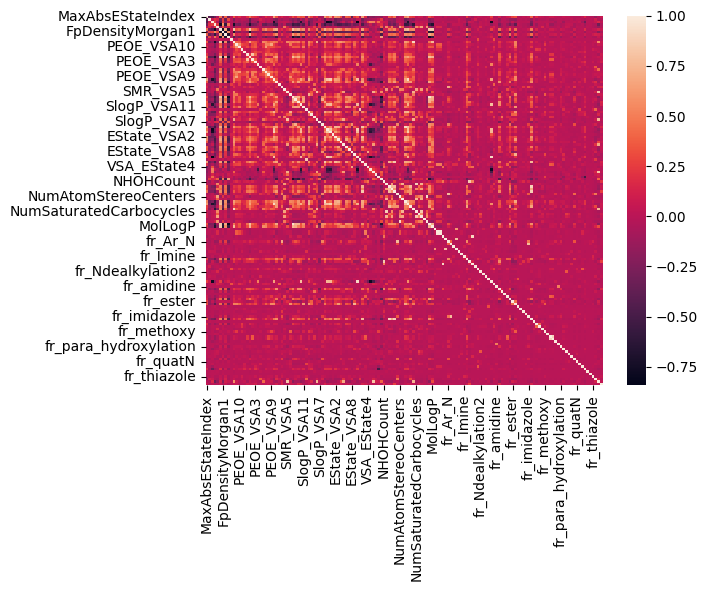

In [33]:
# correlation_matrix = feature_df.iloc[:, 0:148].dropna(axis=1).corr()
# sns.heatmap(correlation_matrix)


In [34]:
# upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
# high_corr_pairs = upper_tri.stack().sort_values(ascending=False)

In [35]:
# to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.85)]
# to_drop = to_drop + ['NumHeterocycles', "NumAmideBonds", "NumSpiroAtoms", "NumAtomStereoCenters", "NumBridgeheadAtoms"]
# print("Columns to drop:", to_drop)

Columns to drop: ['PEOE_VSA14', 'EState_VSA10', 'NumHAcceptors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumUnspecifiedAtomStereoCenters', 'RingCount', 'fr_Al_OH_noTert', 'fr_NH2', 'fr_alkyl_halide', 'fr_imide', 'fr_nitro_arom_nonortho', 'NumHeterocycles', 'NumAmideBonds', 'NumSpiroAtoms', 'NumAtomStereoCenters', 'NumBridgeheadAtoms']


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [26]:
data = pd.concat([train_data, feature_df.reset_index(drop=True)], axis=1)

In [27]:
path_to_models = 'models'
def run_optuna():
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M_%S")
    model_params_log = Path(path_to_models) / f'XGB_{timestamp}'
    model_params_log.mkdir(parents=True, exist_ok=True)
    
    for target in config.TARGET_LIST:
        sub_df = data[data[target].notnull()].drop_duplicates(subset='SMILES', inplace=False, keep='first')
        X = sub_df.filter(items=['id']).join(data.iloc[:, 9:])
        X = X.clip(upper=1e10)
        y = sub_df.loc[:, target]

        with open(f'{path_to_data}/{target}_split.json', 'r') as f:
            target_split = json.load(f)
        
        study_name = f'{target}_XGB'
        
        study = optuna.create_study(direction='minimize', 
                                    sampler=optuna.samplers.TPESampler(seed=SEED), 
                                    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10), 
                                    study_name=study_name)
        study.optimize(lambda trial: objective(trial=trial, datasail_split=target_split, X=X, y=y), n_trials=100, show_progress_bar=True)
        print(f'For target: {target} MAE:{study.best_value}')
        
        target_params = model_params_log / f'{target}_best_params.json'
        with open(target_params , 'w') as f:
            json.dump(study.best_params, f)

In [ ]:
run_optuna()

  0%|          | 0/100 [00:00<?, ?it/s]

In [40]:
def train_model(target, data, parameters_path):
    sub_df = data[data[target].notnull()].drop_duplicates(subset='SMILES', inplace=False, keep='first')
    X = sub_df.filter(items=['id']).join(data.iloc[:, 9:])
    X = X.clip(upper=1e10)
    y = sub_df.loc[:, target]

    params_json = Path(parameters_path) / f'{target}_best_params.json'
    save_path = Path(parameters_path) / f'{target}_model.json'

    with open(params_json, 'r') as f:
        params = json.load(f)

    num_boost_round = params.pop('n_estimators')
    dtrain = xgb.DMatrix(X.drop(columns=['id']), label=y)
    xgb_model = xgb.train(
        params,
        dtrain, 
        num_boost_round=num_boost_round
        )
    
    xgb_model.save_model(str(save_path))
    
    return xgb_model


In [41]:
def predict_model(model, data):
    feature_df = pd.json_normalize(data['SMILES'].apply(config.vectorize_smiles))
    selected_features = feature_df.drop(columns=to_drop)
    dmatrix = xgb.DMatrix(selected_features)
    y_pred = model.predict(dmatrix)
    return y_pred


In [42]:
# results = {'id': test_data['id'].to_list()}
# for target in config.TARGET_LIST:
#     save_path = Path('/kaggle/input/polymer-models/models/XGB_2025-07-21_14_10_15') / f'{target}_model.json'
#     model = xgb.Booster()
#     model.load_model(save_path)
#     prediction = predict_model(model, test_data)
#     results[target] = prediction


In [43]:
selected_columns = selected_features.columns.tolist()
X_test_smiles = test_data['SMILES'].to_list()
pred_matrix = []

for idx, smiles in enumerate(tqdm(X_test_smiles, desc="Predicting test SMILES")):
    try:
        vec = config.vectorize_smiles(smiles)
        if not isinstance(vec, dict):
            vec = {}
    except Exception as e:
        print(f"[ERROR] Failed SMILES at idx={idx} → {e}")
        vec = {}

    try:
        x_vec = pd.DataFrame([vec]).reindex(columns=selected_columns, fill_value=0)
        dtest = xgb.DMatrix(x_vec)
    except Exception as e:
        print(f"[ERROR] Feature alignment failed at idx={idx} → {e}")
        pred_matrix.append([0.0] * len(config.TARGET_LIST))
        continue

    row_preds = []
    for target in config.TARGET_LIST:
        try:
            model_path = Path('/kaggle/input/polymer-models/models/XGB_2025-07-21_14_10_15') / f'{target}_model.json'
            model = xgb.Booster()
            model.load_model(model_path)
            pred = model.predict(dtest)[0]
            row_preds.append(float(pred))
        except Exception as e:
            print(f"[ERROR] Prediction failed for target {target} at idx={idx} → {e}")
            row_preds.append(0.0)

    pred_matrix.append(row_preds)

sample_sub = pd.read_csv('/kaggle/input/neurips-open-polymer-prediction-2025/sample_submission.csv')
submission_df = sample_sub.copy()
submission_df[['Tg', 'FFV', 'Tc', 'Density', 'Rg']] = np.array(pred_matrix)
submission_df.to_csv('submission.csv', index=False)

Predicting test SMILES: 100%|██████████| 3/3 [00:11<00:00,  3.72s/it]


In [ ]:
import joblib

: 